<a href="https://colab.research.google.com/github/RedEgnival/sem-4/blob/main/I069_ML_Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rusheel Sharma
# I069
# ML Lab 6

**Titanic Dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# EDA

In [ ]:
df = pd.read_csv('/content/Lab -6-titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


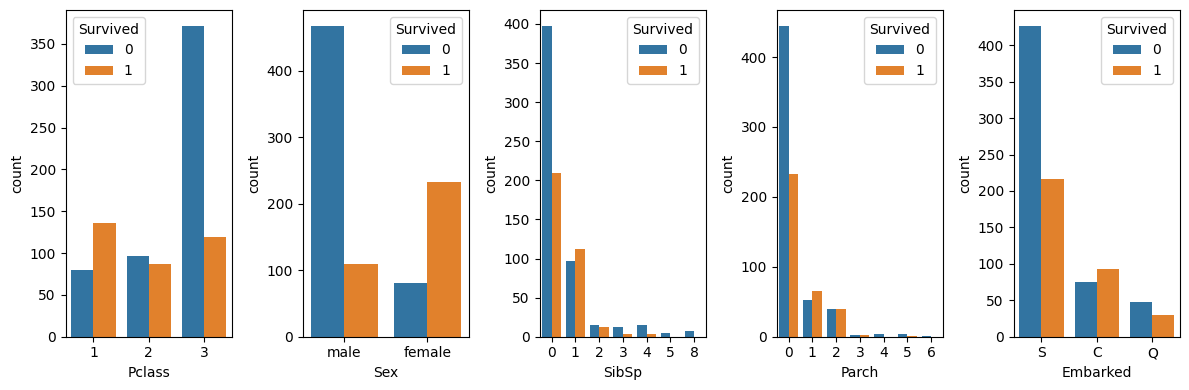

In [ ]:
cols = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

fig, ax = plt.subplots(1, 5, figsize=(12, 4))
index = 0
n = len(cols)
for i in range(n):
    sns.countplot(x=df[cols[index]], hue=df['Survived'], ax=ax[i])
    index += 1

plt.tight_layout()

<Axes: xlabel='Age', ylabel='Count'>

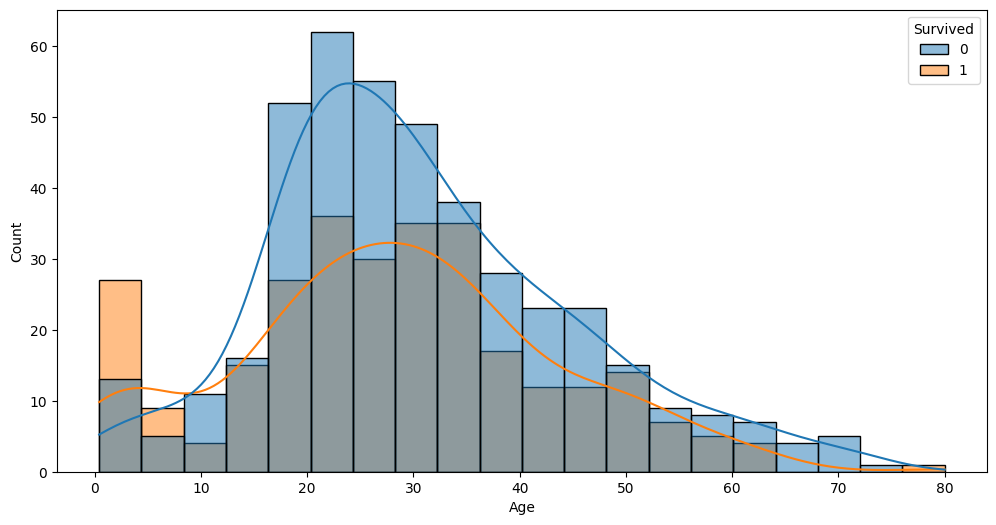

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(x = df['Age'], hue = df['Survived'], kde = True)

<Axes: xlabel='Age', ylabel='count'>

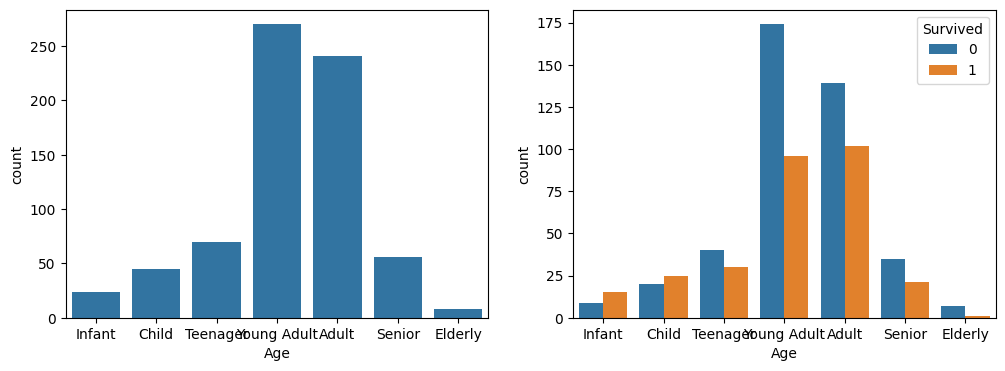

In [ ]:
bins = [0, 2, 12, 18, 30, 50, 65, float('inf')]
labels = ['Infant', 'Child', 'Teenager', 'Young Adult', 'Adult', 'Senior', 'Elderly']
Age_Category = pd.cut(df['Age'], bins=bins, labels=labels)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=Age_Category,  ax=ax[0])
sns.countplot(x=Age_Category, hue=df['Survived'], ax=ax[1])

In [ ]:
print("column Survived:\n", df["Survived"].value_counts())

column Survived:
 Survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
df_missing = df.copy()
df_missing.isna().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Handle missing values

In [ ]:
print(df_missing["Age"].median())
df_missing["Age"] = df_missing["Age"].fillna(df_missing["Age"].median())
df_missing["Age"]

28.0


,Age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


Encoding

In [ ]:
df_encoder = df_missing.copy()
df_encoder

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [ ]:
lbe = LabelEncoder()
df_encoder["Sex"] = lbe.fit_transform(df_encoder["Sex"])
df_encoder["Sex"] #Male = 1

,Sex
0,1
1,0
2,0
3,0
4,1
...,...
886,1
887,0
888,0
889,1


# Model

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, confusion_matrix, classification_report

80-20 Split

In [ ]:
df_train = df_encoder.copy()
df_train.drop(['Fare', 'SibSp', 'Parch', 'Name',"Ticket","Embarked","Cabin"], axis=1, inplace=True)
X = df_train.drop("Survived", axis=1)
y = df_train["Survived"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
df_train

,PassengerId,Survived,Pclass,Sex,Age
0,1,0,3,1,22.0
1,2,1,1,0,38.0
2,3,1,3,0,26.0
3,4,1,1,0,35.0
4,5,0,3,1,35.0
...,...,...,...,...,...
886,887,0,2,1,27.0
887,888,1,1,0,19.0
888,889,0,3,0,28.0
889,890,1,1,1,26.0


In [ ]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)


LogisticRegression(random_state=42)

In [ ]:
y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)


print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"ROC AUC: {roc_auc}")
print(f"Confusion Matrix:\n{conf_matrix}")

Accuracy: 0.7988826815642458
Precision: 0.7794117647058824
Recall: 0.7162162162162162
F1 Score: 0.7464788732394366
ROC AUC: 0.7866795366795367
Confusion Matrix:
[[90 15]
 [21 53]]


In [ ]:
cr = classification_report(y_test, y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



70-30 split

In [ ]:
df_train1 = df_encoder.copy()
df_train1.drop(['Fare', 'SibSp', 'Parch', 'Name',"Ticket","Embarked","Cabin"], axis=1, inplace=True)
X1 = df_train1.drop("Survived", axis=1)
y1 = df_train1["Survived"]
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.3, random_state=42)

In [ ]:
model1 = LogisticRegression()
model1.fit(X1_train, y1_train)

LogisticRegression()

In [ ]:
y1_pred = model1.predict(X1_test)


accuracy1 = accuracy_score(y1_test, y1_pred)
precision1 = precision_score(y1_test, y1_pred)
recall1 = recall_score(y_test, y_pred)
f11 = f1_score(y1_test, y1_pred)
roc_auc1 = roc_auc_score(y1_test, y1_pred)
conf_matrix1 = confusion_matrix(y1_test, y1_pred)


print(f"Accuracy: {accuracy1}")
print(f"Precision: {precision1}")
print(f"Recall: {recall1}")
print(f"F1 Score: {f11}")
print(f"ROC AUC: {roc_auc1}")
print(f"Confusion Matrix:\n{conf_matrix1}")

Accuracy: 0.8059701492537313
Precision: 0.797979797979798
Recall: 0.7162162162162162
F1 Score: 0.7523809523809524
ROC AUC: 0.7921615883399322
Confusion Matrix:
[[137  20]
 [ 32  79]]


In [ ]:
cr1 = classification_report(y1_test, y1_pred)
print(cr1)

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.80      0.71      0.75       111

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.81      0.81      0.80       268



Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
model2 = MultinomialNB()
model2.fit(X1_train, y1_train)

MultinomialNB()

In [ ]:
y2_pred = model2.predict(X1_test)


accuracy1 = accuracy_score(y1_test, y2_pred)
precision1 = precision_score(y1_test, y2_pred)
recall1 = recall_score(y1_test, y2_pred)
f11 = f1_score(y1_test, y2_pred)
roc_auc1 = roc_auc_score(y1_test, y2_pred)
conf_matrix1 = confusion_matrix(y1_test, y2_pred)


print(f"Accuracy: {accuracy1}")
print(f"Precision: {precision1}")
print(f"Recall: {recall1}")
print(f"F1 Score: {f11}")
print(f"ROC AUC: {roc_auc1}")
print(f"Confusion Matrix:\n{conf_matrix1}")

Accuracy: 0.5708955223880597
Precision: 0.4777777777777778
Recall: 0.38738738738738737
F1 Score: 0.42786069651741293
ROC AUC: 0.5440121650312734
Confusion Matrix:
[[110  47]
 [ 68  43]]


In [ ]:
cr2 = classification_report(y1_test, y2_pred)
print(cr2)

              precision    recall  f1-score   support

           0       0.62      0.70      0.66       157
           1       0.48      0.39      0.43       111

    accuracy                           0.57       268
   macro avg       0.55      0.54      0.54       268
weighted avg       0.56      0.57      0.56       268

